# Лабораторная работа №2

In [12]:
import os
import subprocess
import numpy as np
import time
import matplotlib.pyplot as plt

def load_matrix(filename, size):
    if not os.path.isfile(filename):
        raise FileNotFoundError(f"Матрица не найдена: {filename}")
    return np.loadtxt(filename, dtype=int).reshape((size, size))

def verify_multiplication(A_file, B_file, C_file, size):
    A = load_matrix(A_file, size)
    B = load_matrix(B_file, size)
    C_computed = load_matrix(C_file, size)
    C_expected = np.dot(A, B)
    
    if np.array_equal(C_computed, C_expected):
        print(f"✅ Верификация успешна для {size}x{size}")
    else:
        print(f"❌ Ошибка верификации для {size}x{size}")

def run_test(size, num_threads=None, exe_path="matrix_mult/matrix_mult/x64/Debug/matrix_mult.exe"):
    A_file = f"data/{size}/matrix_A.txt"
    B_file = f"data/{size}/matrix_B.txt"
    C_file = f"data/{size}/matrix_C.txt"

    if not os.path.isfile(exe_path):
        raise FileNotFoundError(f"Не найден исполняемый файл: {exe_path}")

    cmd = [exe_path, str(size), A_file, B_file, C_file]
    if num_threads:
        cmd.append(str(num_threads))

    print(f"Запуск: размер = {size}, потоки = {num_threads or 'по умолчанию'}")

    start_time = time.time()
    try:
        subprocess.run(cmd, check=True)
    except subprocess.CalledProcessError as e:
        print(f"Ошибка при запуске внешней программы: {e}")
        return size, None
    end_time = time.time()

    elapsed_time = end_time - start_time
    print(f"Время выполнения = {elapsed_time:.4f} сек")

    verify_multiplication(A_file, B_file, C_file, size)

    return size, elapsed_time

def plot_results(results):
    plt.figure(figsize=(8, 6))
    for threads, data in results.items():
        sizes, times = zip(*data)
        plt.plot(sizes, times, marker='o', label=f'{threads} потоков')
    plt.xlabel("Размер матрицы, N")
    plt.ylabel("Время, сек")
    plt.title("Сравнение времени умножения (OpenMP)")
    plt.grid(True)
    plt.legend(title="Потоки")
    plt.tight_layout()
    plt.show()


In [13]:
sizes = [10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
exe_path = "matrix_mult/matrix_mult/x64/Debug/matrix_mult.exe"
results = {}

# === Тестирование с 1 потоком ===
threads = 1
thread_times = []
for size in sizes:
    s, elapsed = run_test(size, num_threads=threads, exe_path=exe_path)
    thread_times.append((s, elapsed))
results[threads] = thread_times


Запуск: размер = 10, потоки = 1
Время выполнения = 0.0418 сек
✅ Верификация успешна для 10x10
Запуск: размер = 100, потоки = 1
Время выполнения = 0.1210 сек
✅ Верификация успешна для 100x100
Запуск: размер = 200, потоки = 1
Время выполнения = 0.4407 сек
✅ Верификация успешна для 200x200
Запуск: размер = 300, потоки = 1
Время выполнения = 1.0974 сек
✅ Верификация успешна для 300x300
Запуск: размер = 400, потоки = 1
Время выполнения = 2.2867 сек
✅ Верификация успешна для 400x400
Запуск: размер = 500, потоки = 1
Время выполнения = 4.1686 сек
✅ Верификация успешна для 500x500
Запуск: размер = 600, потоки = 1
Время выполнения = 6.5300 сек
✅ Верификация успешна для 600x600
Запуск: размер = 700, потоки = 1
Время выполнения = 10.0312 сек
✅ Верификация успешна для 700x700
Запуск: размер = 800, потоки = 1
Время выполнения = 14.4780 сек
✅ Верификация успешна для 800x800
Запуск: размер = 900, потоки = 1
Время выполнения = 20.5068 сек
✅ Верификация успешна для 900x900
Запуск: размер = 1000, потоки 

In [14]:
threads = 2
thread_times = []
for size in sizes:
    s, elapsed = run_test(size, num_threads=threads, exe_path=exe_path)
    thread_times.append((s, elapsed))
results[threads] = thread_times


Запуск: размер = 10, потоки = 2
Время выполнения = 0.0772 сек
✅ Верификация успешна для 10x10
Запуск: размер = 100, потоки = 2
Время выполнения = 0.1428 сек
✅ Верификация успешна для 100x100
Запуск: размер = 200, потоки = 2
Время выполнения = 0.3939 сек
✅ Верификация успешна для 200x200
Запуск: размер = 300, потоки = 2
Время выполнения = 0.8930 сек
✅ Верификация успешна для 300x300
Запуск: размер = 400, потоки = 2
Время выполнения = 1.7167 сек
✅ Верификация успешна для 400x400
Запуск: размер = 500, потоки = 2
Время выполнения = 2.8551 сек
✅ Верификация успешна для 500x500
Запуск: размер = 600, потоки = 2
Время выполнения = 4.5525 сек
✅ Верификация успешна для 600x600
Запуск: размер = 700, потоки = 2
Время выполнения = 6.5652 сек
✅ Верификация успешна для 700x700
Запуск: размер = 800, потоки = 2
Время выполнения = 9.3130 сек
✅ Верификация успешна для 800x800
Запуск: размер = 900, потоки = 2
Время выполнения = 12.9446 сек
✅ Верификация успешна для 900x900
Запуск: размер = 1000, потоки = 

In [15]:
threads = 4
thread_times = []
for size in sizes:
    s, elapsed = run_test(size, num_threads=threads, exe_path=exe_path)
    thread_times.append((s, elapsed))
results[threads] = thread_times


Запуск: размер = 10, потоки = 4
Время выполнения = 0.0869 сек
✅ Верификация успешна для 10x10
Запуск: размер = 100, потоки = 4
Время выполнения = 0.1083 сек
✅ Верификация успешна для 100x100
Запуск: размер = 200, потоки = 4
Время выполнения = 0.3529 сек
✅ Верификация успешна для 200x200
Запуск: размер = 300, потоки = 4
Время выполнения = 0.7705 сек
✅ Верификация успешна для 300x300
Запуск: размер = 400, потоки = 4
Время выполнения = 1.4085 сек
✅ Верификация успешна для 400x400
Запуск: размер = 500, потоки = 4
Время выполнения = 2.3732 сек
✅ Верификация успешна для 500x500
Запуск: размер = 600, потоки = 4
Время выполнения = 3.5201 сек
✅ Верификация успешна для 600x600
Запуск: размер = 700, потоки = 4
Время выполнения = 4.9646 сек
✅ Верификация успешна для 700x700
Запуск: размер = 800, потоки = 4
Время выполнения = 6.7751 сек
✅ Верификация успешна для 800x800
Запуск: размер = 900, потоки = 4
Время выполнения = 9.2581 сек
✅ Верификация успешна для 900x900
Запуск: размер = 1000, потоки = 4

In [16]:
threads = 6
thread_times = []
for size in sizes:
    s, elapsed = run_test(size, num_threads=threads, exe_path=exe_path)
    thread_times.append((s, elapsed))
results[threads] = thread_times


Запуск: размер = 10, потоки = 6
Время выполнения = 0.0821 сек
✅ Верификация успешна для 10x10
Запуск: размер = 100, потоки = 6
Время выполнения = 0.1281 сек
✅ Верификация успешна для 100x100
Запуск: размер = 200, потоки = 6
Время выполнения = 0.3671 сек
✅ Верификация успешна для 200x200
Запуск: размер = 300, потоки = 6
Время выполнения = 0.7528 сек
✅ Верификация успешна для 300x300
Запуск: размер = 400, потоки = 6
Время выполнения = 1.3709 сек
✅ Верификация успешна для 400x400
Запуск: размер = 500, потоки = 6
Время выполнения = 2.2433 сек
✅ Верификация успешна для 500x500
Запуск: размер = 600, потоки = 6
Время выполнения = 3.1911 сек
✅ Верификация успешна для 600x600
Запуск: размер = 700, потоки = 6
Время выполнения = 4.5371 сек
✅ Верификация успешна для 700x700
Запуск: размер = 800, потоки = 6
Время выполнения = 6.0754 сек
✅ Верификация успешна для 800x800
Запуск: размер = 900, потоки = 6
Время выполнения = 8.1128 сек
✅ Верификация успешна для 900x900
Запуск: размер = 1000, потоки = 6

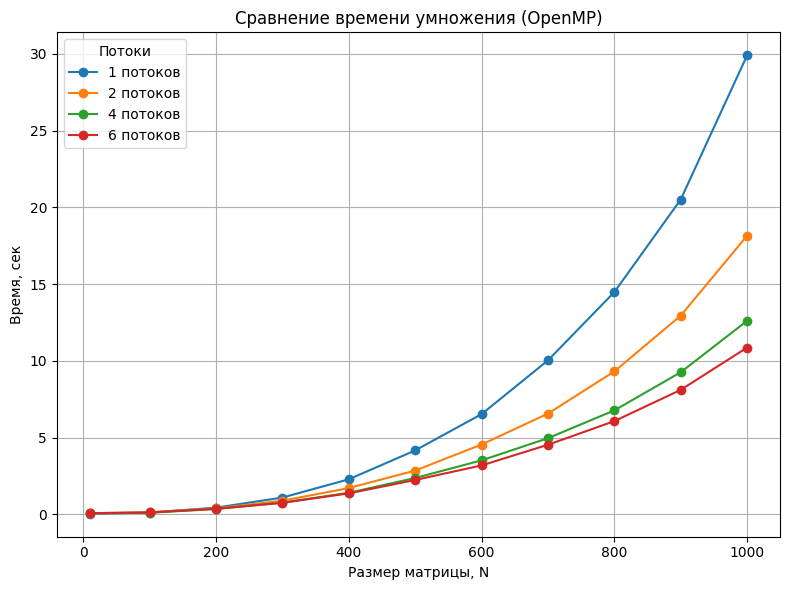

In [17]:
plot_results(results)
